# NBA Draft NLP Model with MLflow Tracking

This notebook:
1. Auto-retrieves new All-Star data
2. Incrementally scrapes only new draft prospect data
3. Trains the NLP model with MLflow tracking for version control and experiment management

## Setup and Imports

In [133]:
import sys
import os
import pandas as pd
import numpy as np
from datetime import datetime
import requests
from bs4 import BeautifulSoup
from IPython.display import clear_output

# MLflow imports
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Sklearn imports
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from scipy.sparse import hstack

# NLP imports
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import pickle

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

# Add data_retrieval to path
sys.path.append(os.path.abspath("../data_retrieval"))
from realgm_retr import get_realgm_allstar_rosters

# Download NLTK data
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)

# Set date string for file naming
date_string = datetime.now().strftime("%Y%m%d")

print(f"Setup complete. Date string: {date_string}")


Setup complete. Date string: 20260308


In [134]:
# Set MLflow tracking URI to SQLite database
mlflow_db_path = os.path.abspath("../data/mlflow_tracking.db")
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path}")

# Set artifact location to local directory
artifact_location = os.path.abspath("../mlruns")

# Set experiment name
experiment_name = "NBA_Draft_AllStar_Prediction"
mlflow.set_experiment(experiment_name)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLflow experiment: {experiment_name}")
print(f"Artifact location: {artifact_location}")

MLflow tracking URI: sqlite:///d:\Andy\python\nba-analysis\data\mlflow_tracking.db
MLflow experiment: NBA_Draft_AllStar_Prediction
Artifact location: d:\Andy\python\nba-analysis\mlruns


In [8]:
def retrieve_allstar_data(start_year=1951, end_year=None):
    """
    Retrieve All-Star roster data from RealGM.
    Only retrieves new data if needed.
    """
    if end_year is None:
        end_year = datetime.now().year

    allstar_file = f"../data/nba_allstar_all_{date_string}.csv"

    # Check if today's file already exists
    if os.path.exists(allstar_file):
        print(f"All-Star data for {date_string} already exists. Loading from file...")
        df = pd.read_csv(allstar_file)
        return df

    # Check for most recent file
    data_dir = "../data"
    allstar_files = [
        f
        for f in os.listdir(data_dir)
        if f.startswith("nba_allstar_all_") and f.endswith(".csv")
    ]

    if allstar_files:
        # Get most recent file
        most_recent = sorted(allstar_files)[-1]
        most_recent_path = os.path.join(data_dir, most_recent)
        existing_df = pd.read_csv(most_recent_path)
        max_existing_year = existing_df["Year"].max()

        # Only retrieve new years
        if max_existing_year >= end_year - 1:
            print(f"Using existing All-Star data from {most_recent}")
            existing_df.to_csv(allstar_file, index=False)
            return existing_df

        print(f"Retrieving All-Star data from {max_existing_year + 1} to {end_year}...")
        new_years = list(range(max_existing_year + 1, end_year))
        new_df = get_realgm_allstar_rosters(new_years)

        # Combine with existing data
        df = pd.concat([existing_df, new_df], ignore_index=True)
    else:
        print(f"Retrieving All-Star data from {start_year} to {end_year}...")
        years = list(range(start_year, end_year))
        df = get_realgm_allstar_rosters(years)

    # Save to file
    df.to_csv(allstar_file, index=False)
    print(f"All-Star data saved to {allstar_file}")

    return df


# Retrieve All-Star data
allstar_df = retrieve_allstar_data()
print(f"\nAll-Star data shape: {allstar_df.shape}")
print(f'Years covered: {allstar_df["Year"].min()} - {allstar_df["Year"].max()}')

Using existing All-Star data from nba_allstar_all_20250528.csv

All-Star data shape: (1844, 10)
Years covered: 1951 - 2025


In [9]:
def get_existing_player_links():
    """
    Load existing player links from the most recent file.
    """
    data_dir = "../data"
    link_files = [
        f
        for f in os.listdir(data_dir)
        if f.startswith("nbadraft_player_links_") and f.endswith(".txt")
    ]

    if not link_files:
        return set()

    most_recent = sorted(link_files)[-1]
    file_path = os.path.join(data_dir, most_recent)

    with open(file_path, "r") as file:
        links = set(line.strip() for line in file.readlines())

    print(f"Loaded {len(links)} existing player links from {most_recent}")
    return links


def scrape_player_links(max_pages=391):
    """
    Scrape player links from nbadraft.net.
    Only scrapes new links not in existing files.
    """
    base_url = "https://www.nbadraft.net/players/"
    existing_links = get_existing_player_links()
    new_links = []

    print(f"Scraping player links from nbadraft.net...")

    for page_num in range(1, max_pages + 1):
        if page_num == 1:
            page_url = base_url
        else:
            page_url = f"{base_url}page/{page_num}/"

        try:
            response = requests.get(page_url, timeout=10)

            if response.status_code == 200:
                soup = BeautifulSoup(response.content, "html.parser")
                parent_div = soup.find("div", class_="wf-container")

                if parent_div:
                    links = parent_div.find_all("a")
                    page_new_links = 0

                    for link in links:
                        href = link.get("href", "")
                        if base_url in href and href not in existing_links:
                            new_links.append(href)
                            page_new_links += 1

                    clear_output(wait=True)
                    print(
                        f"Page {page_num}/{max_pages}: Found {page_new_links} new links (Total new: {len(new_links)})"
                    )
            else:
                print(
                    f"Failed to retrieve page {page_num}. Status code: {response.status_code}"
                )
        except Exception as e:
            print(f"Error on page {page_num}: {str(e)}")
            continue

    # Combine with existing links and save
    all_links = list(existing_links) + new_links
    all_links = list(set(all_links))  # Remove duplicates

    file_path = f"../data/nbadraft_player_links_{date_string}.txt"
    with open(file_path, "w") as file:
        for link in all_links:
            file.write(link + "\n")

    print(f"\nSaved {len(all_links)} total player links to {file_path}")
    print(f"New links found: {len(new_links)}")

    return all_links, new_links


# Scrape player links
all_player_links, new_player_links = scrape_player_links()

Page 391/391: Found 0 new links (Total new: 509)

Saved 8146 total player links to ../data/nbadraft_player_links_20260308.txt
New links found: 509


In [11]:
def get_existing_scraped_players():
    """
    Load existing scraped player data to avoid re-scraping.
    """
    data_dir = "../data"
    data_files = [
        f
        for f in os.listdir(data_dir)
        if f.startswith("nbadraft_strengths_weaknesses_") and f.endswith(".csv")
    ]

    if not data_files:
        return pd.DataFrame(), set()

    most_recent = sorted(data_files)[-1]
    file_path = os.path.join(data_dir, most_recent)
    df = pd.read_csv(file_path)

    existing_players = set(df["player"].values)
    print(f"Loaded {len(existing_players)} existing players from {most_recent}")

    return df, existing_players


def scrape_single_player(player_link):
    """
    Scrape data for a single player.
    Returns tuple: (player_data_dict or None, player_name, success_status)
    """
    player_name = player_link.rsplit("/", 2)[-2]

    try:
        response = requests.get(player_link, timeout=10)

        if response.status_code != 200:
            return None, player_name, "failed"

        soup = BeautifulSoup(response.content, "html.parser")
        weak_obj = None
        strength_obj = None

        # Find strengths and weaknesses
        for identify in ["b", "strong"]:
            for text in ["Strengths:", "Strengths: "]:
                strength_obj = soup.find(identify, text=text)
                if strength_obj is not None:
                    break
            if strength_obj is None:
                continue

            for text in ["Weaknesses:", "Weakness:", "Weaknesses: "]:
                weak_obj = soup.find(identify, text=text)
                if weak_obj is not None:
                    break

            if (strength_obj is not None) and (weak_obj is not None):
                break

        if (weak_obj is None) or (strength_obj is None):
            return None, player_name, "missing_data"

        # Extract text
        try:
            strength_text = strength_obj.find_next_sibling(text=True).strip()
            weak_text = weak_obj.find_next_sibling(text=True).strip()
        except AttributeError:
            try:
                strength_text = strength_obj.find_next_sibling().text.strip()
                weak_text = weak_obj.find_next_sibling().text.strip()
            except AttributeError:
                return None, player_name, "missing_data"

        # Extract year
        try:
            year = int(
                soup.find("div", class_="mock-year")
                .find("span", class_="label")
                .text[:4]
            )
        except AttributeError:
            year = np.nan

        # Extract overall rating
        try:
            overall = int(
                soup.find("div", class_="overall").find("span", class_="value").text
            )
        except AttributeError:
            return None, player_name, "missing_data"

        # Extract attribute scores
        player_attr_obj = soup.find("div", class_="player-attributes")
        attr_values = player_attr_obj.find_all(
            "div", class_="div-table-cell attribute-value"
        )
        attr_names = player_attr_obj.find_all(
            "div", class_="div-table-cell attribute-name"
        )
        attr_dict = {}

        try:
            for name, value in zip(attr_names, attr_values):
                attr_dict[name.text.replace(" ", "")] = int(value.text)
        except ValueError:
            return None, player_name, "missing_data"

        # Build the data dictionary
        player_data = {
            "player": player_name,
            "draft_year": year,
            "strengths": strength_text,
            "weaknesses": weak_text,
            "overall": overall,
        }
        player_data.update(attr_dict)

        return player_data, player_name, "success"

    except Exception as e:
        return None, player_name, "error"


def scrape_player_data(player_links, existing_players=None, n_workers=4):
    """
    Scrape player strengths/weaknesses data in parallel.
    Only scrapes players not in existing_players set.

    Parameters:
    -----------
    player_links : list
        List of player URLs to scrape
    existing_players : set, optional
        Set of player names already scraped (to skip)
    n_workers : int, default=4
        Number of parallel workers for scraping
        Set to 1 for sequential processing

    Returns:
    --------
    df : pd.DataFrame
        DataFrame with scraped player data
    missing_players : list
        List of player names that failed to scrape
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from threading import Lock

    if existing_players is None:
        existing_players = set()

    # Filter out already scraped players
    links_to_scrape = []
    skipped_count = 0

    for link in player_links:
        player_name = link.rsplit("/", 2)[-2]
        if player_name in existing_players:
            skipped_count += 1
        else:
            links_to_scrape.append(link)

    print(f"\nScraping player data:")
    print(f"  Total links: {len(player_links)}")
    print(f"  Already in database (skipped): {skipped_count}")
    print(f"  To scrape: {len(links_to_scrape)}")
    print(f"  Workers: {n_workers}")

    if len(links_to_scrape) == 0:
        print("No new players to scrape!")
        return pd.DataFrame(), []

    data = []
    missing_players = []
    lock = Lock()
    completed = 0

    # Use ThreadPoolExecutor for parallel scraping
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        # Submit all tasks
        future_to_link = {
            executor.submit(scrape_single_player, link): link
            for link in links_to_scrape
        }

        # Process completed tasks
        for future in as_completed(future_to_link):
            player_data, player_name, status = future.result()

            with lock:
                completed += 1

                if status == "success" and player_data is not None:
                    data.append(player_data)
                else:
                    missing_players.append(player_name)

                # Progress update
                if completed % 10 == 0 or completed == len(links_to_scrape):
                    clear_output(wait=True)
                    print(
                        f"Progress: {completed}/{len(links_to_scrape)} | "
                        f"Scraped: {len(data)} | "
                        f"Missing/Failed: {len(missing_players)}"
                    )

    print(f"\nScraping complete!")
    print(f"Successfully scraped: {len(data)} players")
    print(f"Skipped (already in database): {skipped_count} players")
    print(f"Missing/Failed: {len(missing_players)} players")

    return pd.DataFrame(data), missing_players


# Get existing scraped data
existing_df, existing_players = get_existing_scraped_players()

# Scrape only new players (with parallel processing)
# Adjust n_workers based on your needs: higher = faster but more load on the server
# Recommended: 4-8 workers for good balance
new_df, missing_players = scrape_player_data(
    all_player_links, existing_players, n_workers=8
)

# Combine with existing data
if not existing_df.empty and not new_df.empty:
    draftnet_df = pd.concat([existing_df, new_df], ignore_index=True)
elif not new_df.empty:
    draftnet_df = new_df
else:
    draftnet_df = existing_df

# Save combined data
draftnet_file = f"../data/nbadraft_strengths_weaknesses_{date_string}.csv"
draftnet_df.to_csv(draftnet_file, index=False)
print(f"\nSaved {len(draftnet_df)} total players to {draftnet_file}")

Progress: 6692/6692 | Scraped: 48 | Missing/Failed: 6644

Scraping complete!
Successfully scraped: 48 players
Skipped (already in database): 1454 players
Missing/Failed: 6644 players

Saved 1502 total players to ../data/nbadraft_strengths_weaknesses_20260308.csv


In [79]:
import requests
import urllib.parse
from constants import HEADERS
import pandas as pd
from datetime import datetime

url = 'https://stats.nba.com/stats/drafthistory'
params = {
    'College': '',
    'LeagueID': '00',
    'OverallPick': '',
    'RoundNum': '',
    'RoundPick': '',
    'Season': '',
    'TeamID': '0',
    'TopX': '',
}
params_str = urllib.parse.urlencode(params, safe=":+")
response = requests.get(url=url, params=params_str, headers=HEADERS).json()
draft_res= pd.json_normalize(response, 'resultSets')
alltimedraft_df = pd.DataFrame(draft_res["rowSet"][0], columns=draft_res["headers"][0])

# Save draft data
draftnet_file = f"../data/nba_draft_all_time.csv"
alltimedraft_df.to_csv(draftnet_file, index=False)
print(f"\nSaved {len(alltimedraft_df)} total players to {draftnet_file}")


Saved 8374 total players to ../data/nba_draft_all_time.csv


In [151]:
# for getting a column to join on
alltimedraft_df['player'] = alltimedraft_df.PLAYER_NAME.str.lower().str.replace(' ','-')

# Merge draft data with scouting reports
keep_cols = [
    "PERSON_ID",
    "PLAYER_NAME",
    "SEASON",
    "strengths",
    "weaknesses",
    "overall",
    "Athleticism",
    "Size",
    "Defense",
    "Strength",
    "Quickness",
    "Leadership",
    "JumpShot",
    "NBAReady",
    "Rebounding",
    "Potential",
    "PostSkills",
    "Intangibles",
    "BallHandling",
    "Passing",
]

rename_dict = {"PERSON_ID": "person_id", "PLAYER_NAME": "player", "SEASON": "season"}

df = pd.merge(alltimedraft_df, draftnet_df, on="player", how="inner")[keep_cols]
predict_df = draftnet_df[draftnet_df["draft_year"] == 2026].copy() ## for later prediction on 2026 prospects
df.rename(rename_dict, axis=1, inplace=True)
predict_df.rename(rename_dict, axis=1, inplace=True)
df['season'] = df['season'].astype(int)
predict_df['season'] = predict_df['draft_year'].astype(int)
df = df.loc[df.season >= 2006] # earliest year with scouting reports
df = df.dropna(subset=["strengths"])

print(f"\nMerged draft data shape: {df.shape}")
print(f'Seasons covered: {df["season"].min()} - {df["season"].max()}')


Merged draft data shape: (829, 20)
Seasons covered: 2007 - 2025


In [153]:
# Filter All-Star data to relevant years
allstar_df = allstar_df.loc[allstar_df.Year >= 1999]

# Create All-Star indicators
all_star_indicator = []
all_star_first_year = []

for index, row in df.iterrows():
    if row["player"] in allstar_df["Player"].values:
        all_star_indicator.append(1)
        player_allstar = allstar_df.loc[allstar_df["Player"] == row["player"]]
        year_min = player_allstar.Year.min()
        allstar_player_year = year_min - row["season"]
        all_star_first_year.append(allstar_player_year)
    else:
        all_star_indicator.append(0)
        all_star_first_year.append(np.nan)

df["allstar_bool"] = all_star_indicator
df["allstar_first_year"] = all_star_first_year
df["within7"] = (df.allstar_first_year <= 7).astype(int)
df["within5"] = (df.allstar_first_year <= 5).astype(int)

# Remove duplicates
df.drop_duplicates(subset="player", inplace=True)

print(f"\nAll-Star labeling complete:")
print(f"Total players: {len(df)}")
print(f'All-Stars: {df["allstar_bool"].sum()}')
print(f'All-Stars within 5 years: {df["within5"].sum()}')
print(f'All-Stars within 7 years: {df["within7"].sum()}')


All-Star labeling complete:
Total players: 781
All-Stars: 58
All-Stars within 5 years: 45
All-Stars within 7 years: 55


In [154]:
# Calculate current year (for determining if players have had enough time)
current_year = datetime.now().year

# Calculate years since draft
df["years_since_draft"] = current_year - df["season"]

# Define the threshold (7 years for within7 target)
YEARS_THRESHOLD = 7

print(f"\nFiltering players based on time in league:")
print(f"Current year: {current_year}")
print(f"Threshold: {YEARS_THRESHOLD} years")
print(f"Players before filtering: {len(df)}")

# Keep players who:
# 1. Have been in the league for at least YEARS_THRESHOLD years, OR
# 2. Already became an All-Star (regardless of years in league)
df_filtered = df[
    (df["years_since_draft"] >= YEARS_THRESHOLD) | (df["allstar_bool"] == 1)
].copy()

print(f"Players after filtering: {len(df_filtered)}")
print(f"Players removed (not enough time, not All-Stars): {len(df) - len(df_filtered)}")
print(f'All-Stars in filtered data: {df_filtered["allstar_bool"].sum()}')
print(f'All-Stars within 7 years in filtered data: {df_filtered["within7"].sum()}')

# Update df to the filtered version
df = df_filtered


Filtering players based on time in league:
Current year: 2026
Threshold: 7 years
Players before filtering: 781
Players after filtering: 506
Players removed (not enough time, not All-Stars): 275
All-Stars in filtered data: 58
All-Stars within 7 years in filtered data: 55


In [155]:
def preprocess_text(text):
    """
    Preprocess text for NLP:
    - Lowercasing
    - Tokenization
    - Remove punctuation
    - Remove stop words
    - Lemmatization
    """
    # enforce string type and handle NaN
    if not isinstance(text, str):
        return ""

    # Lowercasing
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Removing Punctuation
    tokens = [token for token in tokens if token not in string.punctuation]

    # Removing Stop Words
    stop_words = set(stopwords.words("english"))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Joining tokens back into a single text
    preprocessed_text = " ".join(tokens)

    return preprocessed_text


# Apply preprocessing
print("\nPreprocessing text data...")
df["strengths_processed"] = df["strengths"].apply(preprocess_text)
df["weaknesses_processed"] = df["weaknesses"].apply(preprocess_text)
df["combined_text"] = df["strengths_processed"] + " " + df["weaknesses_processed"]
predict_df["strengths_processed"] = predict_df["strengths"].apply(preprocess_text)
predict_df["weaknesses_processed"] = predict_df["weaknesses"].apply(preprocess_text)
predict_df["combined_text"] = predict_df["strengths_processed"] + " " + predict_df["weaknesses_processed"]

print("Text preprocessing complete!")


Preprocessing text data...
Text preprocessing complete!


In [156]:
print("\nSample original strengths:")
print(df['strengths'].iloc[0])
print("\nSample preprocessed strengths:")
print(df['strengths_processed'].iloc[0])


Sample original strengths:
A generational talent … The sky is the limit and the reality… Has rare potential for a center in today’s NBA … Amazing size for his position with unprecedented length, including a wingspan measured at 8′ feet… Remarkable coordination for a player of his size, length and age… Surprisingly agile and fluid for a human being his size … A jaw dropping physical specimen athlete with hand eye coordination and dexterity … Runs the floor like a deer… Has long strides and covers a lot of ground and finishes plays with solid body control … Has bulked up the last couple of years, body shows that he can add muscle easily without losing mobility and agility … Good basketball I.Q… Versatile player, can be used in either front court position… Makes at least a few “WOW” plays on both ends of the floor in every game… He is a walking mismatch … Good, strong dunker, likes to dunk everything and his length makes him very hard to stop around the rim … Has also some finesse in his

In [183]:
# Configure which NLP experiment to run
# Options: 'baseline', 'separate_vectorizers', 'separate_with_trigrams'
NLP_EXPERIMENT = "separate_vectorizers"  # Change this to switch experiments

print(f"\n{'='*80}")
print(f"NLP EXPERIMENT: {NLP_EXPERIMENT}")
print(f"{'='*80}\n")

if NLP_EXPERIMENT == "baseline":
    print("Using baseline approach: Single vectorizer, bigrams only")
    USE_SEPARATE_VECTORIZERS = False
    NGRAM_RANGE = (1, 2)
    MAX_FEATURES_PER_FIELD = 500
elif NLP_EXPERIMENT == "separate_vectorizers":
    print("Using Experiment 1: Separate vectorizers for strengths/weaknesses, bigrams")
    USE_SEPARATE_VECTORIZERS = True
    NGRAM_RANGE = (3, 4)
    MAX_FEATURES_PER_FIELD = 500  # 400 per field = 800 total text features
elif NLP_EXPERIMENT == "separate_with_trigrams":
    print("Using Experiment 2: Separate vectorizers with trigrams")
    USE_SEPARATE_VECTORIZERS = True
    NGRAM_RANGE = (1, 3)
    MAX_FEATURES_PER_FIELD = 600  # 600 per field = 1200 total text features
else:
    raise ValueError(f"Unknown NLP_EXPERIMENT: {NLP_EXPERIMENT}")


NLP EXPERIMENT: separate_vectorizers

Using Experiment 1: Separate vectorizers for strengths/weaknesses, bigrams


In [184]:
# Define target variable (All-Star within 5 years)
target_col = "within7"

# Separate training data (has labels) from prediction data (2025 prospects)
train_df = df[df[target_col].notna()].copy()

print(f"\nTraining data: {len(train_df)} players")
print(f"Prediction data (unlabeled): {len(predict_df)} players")

# Prepare text features based on experiment configuration
if USE_SEPARATE_VECTORIZERS:
    X_strengths = train_df["strengths_processed"]
    X_weaknesses = train_df["weaknesses_processed"]
    print(f"\nUsing separate text features:")
    print(f"  Strengths: {len(X_strengths)} samples")
    print(f"  Weaknesses: {len(X_weaknesses)} samples")
else:
    X_text = train_df["combined_text"]
    print(f"\nUsing combined text features: {len(X_text)} samples")

y = train_df[target_col]

# Numerical features
numerical_features = [
    "overall",
    "Athleticism",
    "Size",
    "Defense",
    "Strength",
    "Quickness",
    "Leadership",
    "JumpShot",
    "NBAReady",
]

# Fill NaN values in numerical features with median
for col in numerical_features:
    if col in train_df.columns:
        median_val = train_df[col].median()
        train_df[col].fillna(median_val, inplace=True)

X_numerical = train_df[numerical_features]

print(f"Numerical features: {X_numerical.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")


Training data: 506 players
Prediction data (unlabeled): 26 players

Using separate text features:
  Strengths: 506 samples
  Weaknesses: 506 samples
Numerical features: (506, 9)
Target distribution: {0: 451, 1: 55}


C:\Users\Andy\AppData\Local\Temp\ipykernel_10624\796355208.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(median_val, inplace=True)
C:\Users\Andy\AppData\Local\Temp\ipykernel_10624\796355208.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [185]:
# Split data based on experiment configuration
if USE_SEPARATE_VECTORIZERS:
    (
        X_str_train,
        X_str_test,
        X_weak_train,
        X_weak_test,
        X_num_train,
        X_num_test,
        y_train,
        y_test,
    ) = train_test_split(
        X_strengths,
        X_weaknesses,
        X_numerical,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )
    print(f"\nTrain-test split complete:")
    print(f"Training samples: {len(X_str_train)}")
    print(f"Test samples: {len(X_str_test)}")
else:
    X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = (
        train_test_split(
            X_text, X_numerical, y, test_size=0.2, random_state=42, stratify=y
        )
    )
    print(f"\nTrain-test split complete:")
    print(f"Training samples: {len(X_text_train)}")
    print(f"Test samples: {len(X_text_test)}")

print(f"Training target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")


Train-test split complete:
Training samples: 404
Test samples: 102
Training target distribution: {0: 360, 1: 44}
Test target distribution: {0: 91, 1: 11}


In [197]:
# Start MLflow run
with mlflow.start_run(run_name=f"NBA_Draft_NLP_{date_string}") as run:

    print(f'\n{"="*80}')
    print(f"MLflow Run ID: {run.info.run_id}")
    print(f'{"="*80}\n')

    # Log experiment configuration
    mlflow.log_param("nlp_experiment", NLP_EXPERIMENT)
    mlflow.log_param("use_separate_vectorizers", USE_SEPARATE_VECTORIZERS)
    mlflow.log_param("ngram_range", str(NGRAM_RANGE))
    mlflow.log_param("max_features_per_field", MAX_FEATURES_PER_FIELD)
    mlflow.log_param("target_variable", target_col)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("test_split", 0.2)
    mlflow.log_param("tfidf_min_df", 2)
    mlflow.log_param("tfidf_max_df", 0.8)

    # TF-IDF Vectorization based on experiment configuration
    print("Performing TF-IDF vectorization...")

    if USE_SEPARATE_VECTORIZERS:
        # Experiment 1 & 2: Separate vectorizers for strengths and weaknesses
        print(f"Using separate vectorizers with ngram_range={NGRAM_RANGE}")

        vectorizer_strengths = TfidfVectorizer(
            max_features=MAX_FEATURES_PER_FIELD,
            ngram_range=NGRAM_RANGE,
            min_df=2,
            max_df=0.8,
            sublinear_tf=True,
        )

        vectorizer_weaknesses = TfidfVectorizer(
            max_features=MAX_FEATURES_PER_FIELD,
            ngram_range=NGRAM_RANGE,
            min_df=2,
            max_df=0.8,
            sublinear_tf=True,
        )

        # Transform strengths
        X_str_train_tfidf = vectorizer_strengths.fit_transform(X_str_train)
        X_str_test_tfidf = vectorizer_strengths.transform(X_str_test)

        # Transform weaknesses
        X_weak_train_tfidf = vectorizer_weaknesses.fit_transform(X_weak_train)
        X_weak_test_tfidf = vectorizer_weaknesses.transform(X_weak_test)

        print(f"Strengths TF-IDF shape: {X_str_train_tfidf.shape}")
        print(f"Weaknesses TF-IDF shape: {X_weak_train_tfidf.shape}")

        # Combine all features: strengths + weaknesses + numerical
        X_train_combined = hstack(
            [X_str_train_tfidf, X_weak_train_tfidf, X_num_train.values]
        )
        X_test_combined = hstack(
            [X_str_test_tfidf, X_weak_test_tfidf, X_num_test.values]
        )

        total_text_features = X_str_train_tfidf.shape[1] + X_weak_train_tfidf.shape[1]
        mlflow.log_param("total_text_features", total_text_features)
        mlflow.log_param("strengths_features", X_str_train_tfidf.shape[1])
        mlflow.log_param("weaknesses_features", X_weak_train_tfidf.shape[1])
        mlflow.log_param("train_size", len(X_str_train))
        mlflow.log_param("test_size", len(X_str_test))

    else:
        # Baseline: Single vectorizer for combined text
        print(f"Using single vectorizer with ngram_range={NGRAM_RANGE}")

        vectorizer = TfidfVectorizer(
            max_features=MAX_FEATURES_PER_FIELD,
            ngram_range=NGRAM_RANGE,
            min_df=2,
            max_df=0.8,
        )

        X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
        X_text_test_tfidf = vectorizer.transform(X_text_test)

        print(f"TF-IDF shape: {X_text_train_tfidf.shape}")

        # Combine text and numerical features
        X_train_combined = hstack([X_text_train_tfidf, X_num_train.values])
        X_test_combined = hstack([X_text_test_tfidf, X_num_test.values])

        mlflow.log_param("total_text_features", X_text_train_tfidf.shape[1])
        mlflow.log_param("train_size", len(X_text_train))
        mlflow.log_param("test_size", len(X_text_test))

    print(f"Combined feature shape: {X_train_combined.shape}")
    mlflow.log_param("total_features", X_train_combined.shape[1])
    mlflow.log_param("numerical_features", len(numerical_features))

    # Hyperparameter tuning with GridSearchCV
    print("\nPerforming hyperparameter tuning...")

    param_grid = {
        "C": [0.1, 1.0, 10.0],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
        "max_iter": [2000],
        "class_weight": ["balanced", None],  # Try both balanced and unbalanced
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        LogisticRegression(random_state=42),
        param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        verbose=1,
    )

    grid_search.fit(X_train_combined, y_train)

    # Log best parameters
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

    for param, value in grid_search.best_params_.items():
        mlflow.log_param(f"best_{param}", value)

    mlflow.log_metric("best_cv_f1_score", grid_search.best_score_)

    # Get best model
    best_model = grid_search.best_estimator_

    # Cross-validation metrics
    print("\nPerforming cross-validation...")
    cv_results = cross_validate(
        best_model,
        X_train_combined,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        return_train_score=True,
    )

    # Log CV metrics
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        train_metric = cv_results[f"train_{metric}"].mean()
        test_metric = cv_results[f"test_{metric}"].mean()

        mlflow.log_metric(f"cv_train_{metric}", train_metric)
        mlflow.log_metric(f"cv_test_{metric}", test_metric)

        print(f"CV {metric.upper()}: Train={train_metric:.4f}, Test={test_metric:.4f}")

    # Train final model on full training set
    print("\nTraining final model on full training set...")
    best_model.fit(X_train_combined, y_train)

    # Predictions on test set
    y_pred = best_model.predict(X_test_combined)
    y_pred_proba = best_model.predict_proba(X_test_combined)[:, 1]

    # Calculate test metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Log test metrics
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1", test_f1)
    mlflow.log_metric("test_roc_auc", test_roc_auc)

    print(f'\n{"="*80}')
    print("TEST SET PERFORMANCE:")
    print(f'{"="*80}')
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"ROC AUC:   {test_roc_auc:.4f}")
    print(f'{"="*80}\n')

    # Classification report
    class_report = classification_report(y_test, y_pred)
    print("Classification Report:")
    print(class_report)

    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(conf_matrix)

    # Log confusion matrix
    mlflow.log_metric("true_negatives", int(conf_matrix[0, 0]))
    mlflow.log_metric("false_positives", int(conf_matrix[0, 1]))
    mlflow.log_metric("false_negatives", int(conf_matrix[1, 0]))
    mlflow.log_metric("true_positives", int(conf_matrix[1, 1]))

    # =============================================================================
    # Threshold Tuning - Find optimal decision threshold
    # =============================================================================
    print(f'\n{"="*80}')
    print("THRESHOLD TUNING:")
    print(f'{"="*80}')
    print("Finding optimal decision threshold to maximize F1 score...\n")

    # Try different thresholds
    thresholds = np.arange(0.1, 0.9, 0.05)
    f1_scores = []

    for thresh in thresholds:
        y_pred_thresh = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_test, y_pred_thresh)
        f1_scores.append(f1)
        print(f"Threshold: {thresh:.2f}, F1: {f1:.4f}")

    best_threshold = thresholds[np.argmax(f1_scores)]
    best_f1 = max(f1_scores)

    print(f"\nBest threshold: {best_threshold:.2f}")
    print(f"Best F1: {best_f1:.4f}")
    print(f"Default threshold (0.5) F1: {test_f1:.4f}")
    print(
        f"Improvement: {((best_f1 - test_f1) / test_f1 * 100):.1f}% increase in F1 score"
    )
    print(f'{"="*80}\n')

    # Log optimal threshold metrics to MLflow
    mlflow.log_metric("optimal_threshold", best_threshold)
    mlflow.log_metric("optimal_f1", best_f1)
    mlflow.log_metric("f1_improvement_pct", (best_f1 - test_f1) / test_f1 * 100)

    # =============================================================================
    # Feature Importance Analysis
    # =============================================================================
    print(f'\n{"="*80}')
    print("FEATURE IMPORTANCE ANALYSIS:")
    print(f'{"="*80}\n')

    # Get feature names
    if USE_SEPARATE_VECTORIZERS:
        str_features = [
            "STR_" + f for f in vectorizer_strengths.get_feature_names_out()
        ]
        weak_features = [
            "WEAK_" + f for f in vectorizer_weaknesses.get_feature_names_out()
        ]
        all_feature_names = str_features + weak_features + numerical_features
    else:
        all_feature_names = (
            vectorizer.get_feature_names_out().tolist() + numerical_features
        )

    # Get coefficients from the logistic regression model
    coefficients = best_model.coef_[0]

    # Create feature importance dataframe
    feature_importance_df = pd.DataFrame(
        {"feature": all_feature_names, "coefficient": coefficients}
    )

    # Add absolute value for ranking
    feature_importance_df["abs_coefficient"] = np.abs(
        feature_importance_df["coefficient"]
    )

    # Sort by absolute coefficient
    feature_importance_df = feature_importance_df.sort_values(
        "abs_coefficient", ascending=False
    )

    # Separate into positive (All-Star indicators) and negative (Non-All-Star indicators)
    positive_features = feature_importance_df[
        feature_importance_df["coefficient"] > 0
    ].head(20)
    negative_features = feature_importance_df[
        feature_importance_df["coefficient"] < 0
    ].head(20)

    print("Top 20 Features Predicting ALL-STAR:")
    print("=" * 80)
    for idx, row in positive_features.iterrows():
        print(f"{row['feature']:50s} | Coefficient: {row['coefficient']:+.4f}")

    print(f'\n{"="*80}')
    print("Top 20 Features Predicting NON-ALL-STAR:")
    print("=" * 80)
    for idx, row in negative_features.iterrows():
        print(f"{row['feature']:50s} | Coefficient: {row['coefficient']:+.4f}")

    # =============================================================================
    # Visualization 1: Top 20 Most Important Features (by absolute value)
    # =============================================================================
    print(f'\n{"="*80}')
    print("Creating feature importance visualizations...")
    print(f'{"="*80}\n')

    top_features = feature_importance_df.head(20)

    plt.figure(figsize=(12, 8))
    colors = ["green" if x > 0 else "red" for x in top_features["coefficient"]]
    plt.barh(range(len(top_features)), top_features["coefficient"], color=colors)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Coefficient (Impact on All-Star Prediction)", fontsize=12)
    plt.title(
        "Top 20 Most Important Features\n(Green = All-Star Indicator, Red = Non-All-Star Indicator)",
        fontsize=14,
        fontweight="bold",
    )
    plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.savefig("feature_importance_top20.png", dpi=300, bbox_inches="tight")
    mlflow.log_artifact("feature_importance_top20.png")
    plt.close()
    print("✓ Saved: feature_importance_top20.png")

    # =============================================================================
    # Visualization 2: Separate Strengths vs Weaknesses (if applicable)
    # =============================================================================
    if USE_SEPARATE_VECTORIZERS:
        # Separate strengths and weaknesses features
        str_feature_importance = feature_importance_df[
            feature_importance_df["feature"].str.startswith("STR_")
        ].head(15)
        weak_feature_importance = feature_importance_df[
            feature_importance_df["feature"].str.startswith("WEAK_")
        ].head(15)

        # Create side-by-side comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Strengths
        colors1 = [
            "green" if x > 0 else "red" for x in str_feature_importance["coefficient"]
        ]
        ax1.barh(
            range(len(str_feature_importance)),
            str_feature_importance["coefficient"],
            color=colors1,
        )
        ax1.set_yticks(range(len(str_feature_importance)))
        ax1.set_yticklabels(
            [f.replace("STR_", "") for f in str_feature_importance["feature"]]
        )
        ax1.set_xlabel("Coefficient", fontsize=11)
        ax1.set_title("Top 15 STRENGTHS Features", fontsize=13, fontweight="bold")
        ax1.axvline(x=0, color="black", linestyle="--", linewidth=0.8)

        # Weaknesses
        colors2 = [
            "green" if x > 0 else "red" for x in weak_feature_importance["coefficient"]
        ]
        ax2.barh(
            range(len(weak_feature_importance)),
            weak_feature_importance["coefficient"],
            color=colors2,
        )
        ax2.set_yticks(range(len(weak_feature_importance)))
        ax2.set_yticklabels(
            [f.replace("WEAK_", "") for f in weak_feature_importance["feature"]]
        )
        ax2.set_xlabel("Coefficient", fontsize=11)
        ax2.set_title("Top 15 WEAKNESSES Features", fontsize=13, fontweight="bold")
        ax2.axvline(x=0, color="black", linestyle="--", linewidth=0.8)

        plt.suptitle(
            "Feature Importance: Strengths vs Weaknesses",
            fontsize=15,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.savefig(
            "feature_importance_strengths_vs_weaknesses.png",
            dpi=300,
            bbox_inches="tight",
        )
        mlflow.log_artifact("feature_importance_strengths_vs_weaknesses.png")
        plt.close()
        print("✓ Saved: feature_importance_strengths_vs_weaknesses.png")

    # =============================================================================
    # Visualization 3: Numerical Features Importance
    # =============================================================================
    numerical_feature_importance = feature_importance_df[
        feature_importance_df["feature"].isin(numerical_features)
    ].sort_values("coefficient", ascending=True)

    if len(numerical_feature_importance) > 0:
        plt.figure(figsize=(10, 6))
        colors = [
            "green" if x > 0 else "red"
            for x in numerical_feature_importance["coefficient"]
        ]
        plt.barh(
            range(len(numerical_feature_importance)),
            numerical_feature_importance["coefficient"],
            color=colors,
        )
        plt.yticks(
            range(len(numerical_feature_importance)),
            numerical_feature_importance["feature"],
        )
        plt.xlabel("Coefficient", fontsize=12)
        plt.title(
            "Numerical Features Importance\n(Green = All-Star Indicator, Red = Non-All-Star Indicator)",
            fontsize=14,
            fontweight="bold",
        )
        plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
        plt.tight_layout()
        plt.savefig("feature_importance_numerical.png", dpi=300, bbox_inches="tight")
        mlflow.log_artifact("feature_importance_numerical.png")
        plt.close()
        print("✓ Saved: feature_importance_numerical.png")

    # =============================================================================
    # Save Feature Importance CSV
    # =============================================================================
    feature_importance_df.to_csv("feature_importance.csv", index=False)
    mlflow.log_artifact("feature_importance.csv")
    os.remove("feature_importance.csv")
    print("✓ Saved: feature_importance.csv")

    print(f'\n{"="*80}')
    print("Feature importance analysis complete!")
    print(f'{"="*80}\n')

    # Save artifacts
    print("\nSaving artifacts...")

    # Save classification report
    with open("classification_report.txt", "w") as f:
        f.write(class_report)
    mlflow.log_artifact("classification_report.txt")
    os.remove("classification_report.txt")

    # Save confusion matrix
    with open("confusion_matrix.txt", "w") as f:
        f.write(str(conf_matrix))
    mlflow.log_artifact("confusion_matrix.txt")
    os.remove("confusion_matrix.txt")

    # Save feature names
    if USE_SEPARATE_VECTORIZERS:
        str_features = [
            "STR_" + f for f in vectorizer_strengths.get_feature_names_out()
        ]
        weak_features = [
            "WEAK_" + f for f in vectorizer_weaknesses.get_feature_names_out()
        ]
        feature_names = str_features + weak_features + numerical_features
    else:
        feature_names = vectorizer.get_feature_names_out().tolist() + numerical_features

    with open("feature_names.txt", "w") as f:
        for name in feature_names:
            f.write(f"{name}\n")
    mlflow.log_artifact("feature_names.txt")
    os.remove("feature_names.txt")

    # Save vectorizer(s)
    if USE_SEPARATE_VECTORIZERS:
        with open("tfidf_vectorizer_strengths.pkl", "wb") as f:
            pickle.dump(vectorizer_strengths, f)
        with open("tfidf_vectorizer_weaknesses.pkl", "wb") as f:
            pickle.dump(vectorizer_weaknesses, f)
        mlflow.log_artifact("tfidf_vectorizer_strengths.pkl")
        mlflow.log_artifact("tfidf_vectorizer_weaknesses.pkl")
        os.remove("tfidf_vectorizer_strengths.pkl")
        os.remove("tfidf_vectorizer_weaknesses.pkl")
    else:
        with open("tfidf_vectorizer.pkl", "wb") as f:
            pickle.dump(vectorizer, f)
        mlflow.log_artifact("tfidf_vectorizer.pkl")
        os.remove("tfidf_vectorizer.pkl")

    # Log model with signature
    print("Logging model to MLflow...")
    signature = infer_signature(X_train_combined, best_model.predict(X_train_combined))
    mlflow.sklearn.log_model(
        best_model,
        "model",
        signature=signature,
        registered_model_name="NBA_Draft_AllStar_Predictor",
    )

    print(f'\n{"="*80}')
    print("MLflow logging complete!")
    print(f"Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")
    print(f'{"="*80}\n')


MLflow Run ID: 7b3d6555a9734e719a42d72ee92f7c40

Performing TF-IDF vectorization...
Using separate vectorizers with ngram_range=(3, 4)
Strengths TF-IDF shape: (404, 500)
Weaknesses TF-IDF shape: (404, 500)
Combined feature shape: (404, 1009)

Performing hyperparameter tuning...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best parameters: {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 score: 0.4290

Performing cross-validation...
CV ACCURACY: Train=0.9394, Test=0.8515
CV PRECISION: Train=0.6428, Test=0.3621
CV RECALL: Train=1.0000, Test=0.5639
CV F1: Train=0.7824, Test=0.4290
CV ROC_AUC: Train=0.9929, Test=0.7903

Training final model on full training set...

TEST SET PERFORMANCE:
Accuracy:  0.8039
Precision: 0.2857
Recall:    0.5455
F1 Score:  0.3750
ROC AUC:   0.8362

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88        91
           1 

2026/03/08 22:24:23 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/03/08 22:24:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 22:24:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ Saved: feature_importance_numerical.png
✓ Saved: feature_importance.csv

Feature importance analysis complete!


Saving artifacts...
Logging model to MLflow...

MLflow logging complete!
Run ID: 7b3d6555a9734e719a42d72ee92f7c40
Experiment ID: 1



Registered model 'NBA_Draft_AllStar_Predictor' already exists. Creating a new version of this model...
Created version '20' of model 'NBA_Draft_AllStar_Predictor'.


In [191]:
print("\n" + "=" * 80)
print("PREDICTING 2026 DRAFT PROSPECTS")
print("=" * 80 + "\n")

if len(predict_df) > 0:
    # Fill NaN values in numerical features
    for col in numerical_features:
        if col in predict_df.columns:
            median_val = train_df[col].median()
            predict_df[col].fillna(median_val, inplace=True)

    X_predict_numerical = predict_df[numerical_features]

    # Transform text features based on experiment configuration
    if USE_SEPARATE_VECTORIZERS:
        X_predict_strengths = predict_df["strengths_processed"]
        X_predict_weaknesses = predict_df["weaknesses_processed"]

        X_predict_str_tfidf = vectorizer_strengths.transform(X_predict_strengths)
        X_predict_weak_tfidf = vectorizer_weaknesses.transform(X_predict_weaknesses)

        # Combine features
        X_predict_combined = hstack(
            [X_predict_str_tfidf, X_predict_weak_tfidf, X_predict_numerical.values]
        )
    else:
        X_predict_text = predict_df["combined_text"]
        X_predict_text_tfidf = vectorizer.transform(X_predict_text)

        # Combine features
        X_predict_combined = hstack([X_predict_text_tfidf, X_predict_numerical.values])

    # Make predictions
    predictions = best_model.predict(X_predict_combined)
    prediction_probas = best_model.predict_proba(X_predict_combined)[:, 1]

    # Add predictions to dataframe
    predict_df["allstar_prediction"] = predictions
    predict_df["allstar_probability"] = prediction_probas

    # Sort by probability
    predict_df_sorted = predict_df.sort_values("allstar_probability", ascending=False)

    # Display top prospects
    print("Top 2025 Draft Prospects (by All-Star probability):")
    print("=" * 80)

    display_cols = ["player", "overall", "allstar_prediction", "allstar_probability"]
    top_prospects = predict_df_sorted[display_cols].head(20)

    for idx, row in top_prospects.iterrows():
        prediction_label = (
            "ALL-STAR" if row["allstar_prediction"] == 1 else "Not All-Star"
        )
        print(
            f"{row['player']:30s} | Overall: {row['overall']:2.0f} | {prediction_label:15s} | Prob: {row['allstar_probability']:.3f}"
        )

    # Save predictions
    predictions_file = f"../data/nba_draft_2025_predictions_{date_string}.csv"
    predict_df_sorted.to_csv(predictions_file, index=False)
    print(f"\nPredictions saved to: {predictions_file}")

    # Summary statistics
    print(f'\n{"="*80}')
    print("PREDICTION SUMMARY:")
    print(f'{"="*80}')
    print(f"Total 2025 prospects: {len(predict_df)}")
    print(f"Predicted All-Stars: {predictions.sum()}")
    print(f"Predicted Non-All-Stars: {len(predictions) - predictions.sum()}")
    print(f"Average All-Star probability: {prediction_probas.mean():.3f}")
    print(f'{"="*80}\n')
else:
    print("No unlabeled prospects found for prediction.")

print("\n" + "=" * 80)
print("SCRIPT COMPLETE!")
print("=" * 80)
print("\nTo view MLflow results, run:")
print("  mlflow ui")
print("\nThen open http://localhost:5000 in your browser.")
print("=" * 80)


PREDICTING 2026 DRAFT PROSPECTS

Top 2025 Draft Prospects (by All-Star probability):
aj-dybantsa                    | Overall: 104 | ALL-STAR        | Prob: 0.990
darryn-peterson                | Overall: 100 | ALL-STAR        | Prob: 0.955
cameron-boozer                 | Overall: 99 | ALL-STAR        | Prob: 0.945
dj-wagner                      | Overall: 96 | ALL-STAR        | Prob: 0.800
boogie-fland                   | Overall: 94 | ALL-STAR        | Prob: 0.748
keaton-wagler                  | Overall: 95 | ALL-STAR        | Prob: 0.727
darius-acuff                   | Overall: 91 | ALL-STAR        | Prob: 0.597
jayden-quaintance              | Overall: 96 | ALL-STAR        | Prob: 0.530
chris-cenac                    | Overall: 94 | Not All-Star    | Prob: 0.492
aaron-bradshaw                 | Overall: 94 | Not All-Star    | Prob: 0.485
kingston-flemings              | Overall: 97 | Not All-Star    | Prob: 0.464
meleek-thomas                  | Overall: 92 | Not All-Star    | 

C:\Users\Andy\AppData\Local\Temp\ipykernel_10624\2251882699.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  predict_df[col].fillna(median_val, inplace=True)
C:\Users\Andy\AppData\Local\Temp\ipykernel_10624\2251882699.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa


CONFUSION MATRIX ANALYSIS

Threshold Comparison:

Threshold: 0.5
  Confusion Matrix:
    TN:  76  |  FP:  15
    FN:   5  |  TP:   6
  Metrics:
    Precision: 0.286  |  Recall: 0.545  |  F1: 0.375  |  Accuracy: 0.804
  Predictions:
    All-Stars: 21 (20.6%)
    Non-All-Stars: 81 (79.4%)

Threshold: 0.65
  Confusion Matrix:
    TN:  86  |  FP:   5
    FN:   6  |  TP:   5
  Metrics:
    Precision: 0.500  |  Recall: 0.455  |  F1: 0.476  |  Accuracy: 0.892
  Predictions:
    All-Stars: 10 (9.8%)
    Non-All-Stars: 92 (90.2%)

Threshold: 0.75
  Confusion Matrix:
    TN:  89  |  FP:   2
    FN:   7  |  TP:   4
  Metrics:
    Precision: 0.667  |  Recall: 0.364  |  F1: 0.471  |  Accuracy: 0.912
  Predictions:
    All-Stars: 6 (5.9%)
    Non-All-Stars: 96 (94.1%)

Threshold: 0.9
  Confusion Matrix:
    TN:  90  |  FP:   1
    FN:   9  |  TP:   2
  Metrics:
    Precision: 0.667  |  Recall: 0.182  |  F1: 0.286  |  Accuracy: 0.902
  Predictions:
    All-Stars: 3 (2.9%)
    Non-All-Stars: 99 (97.1

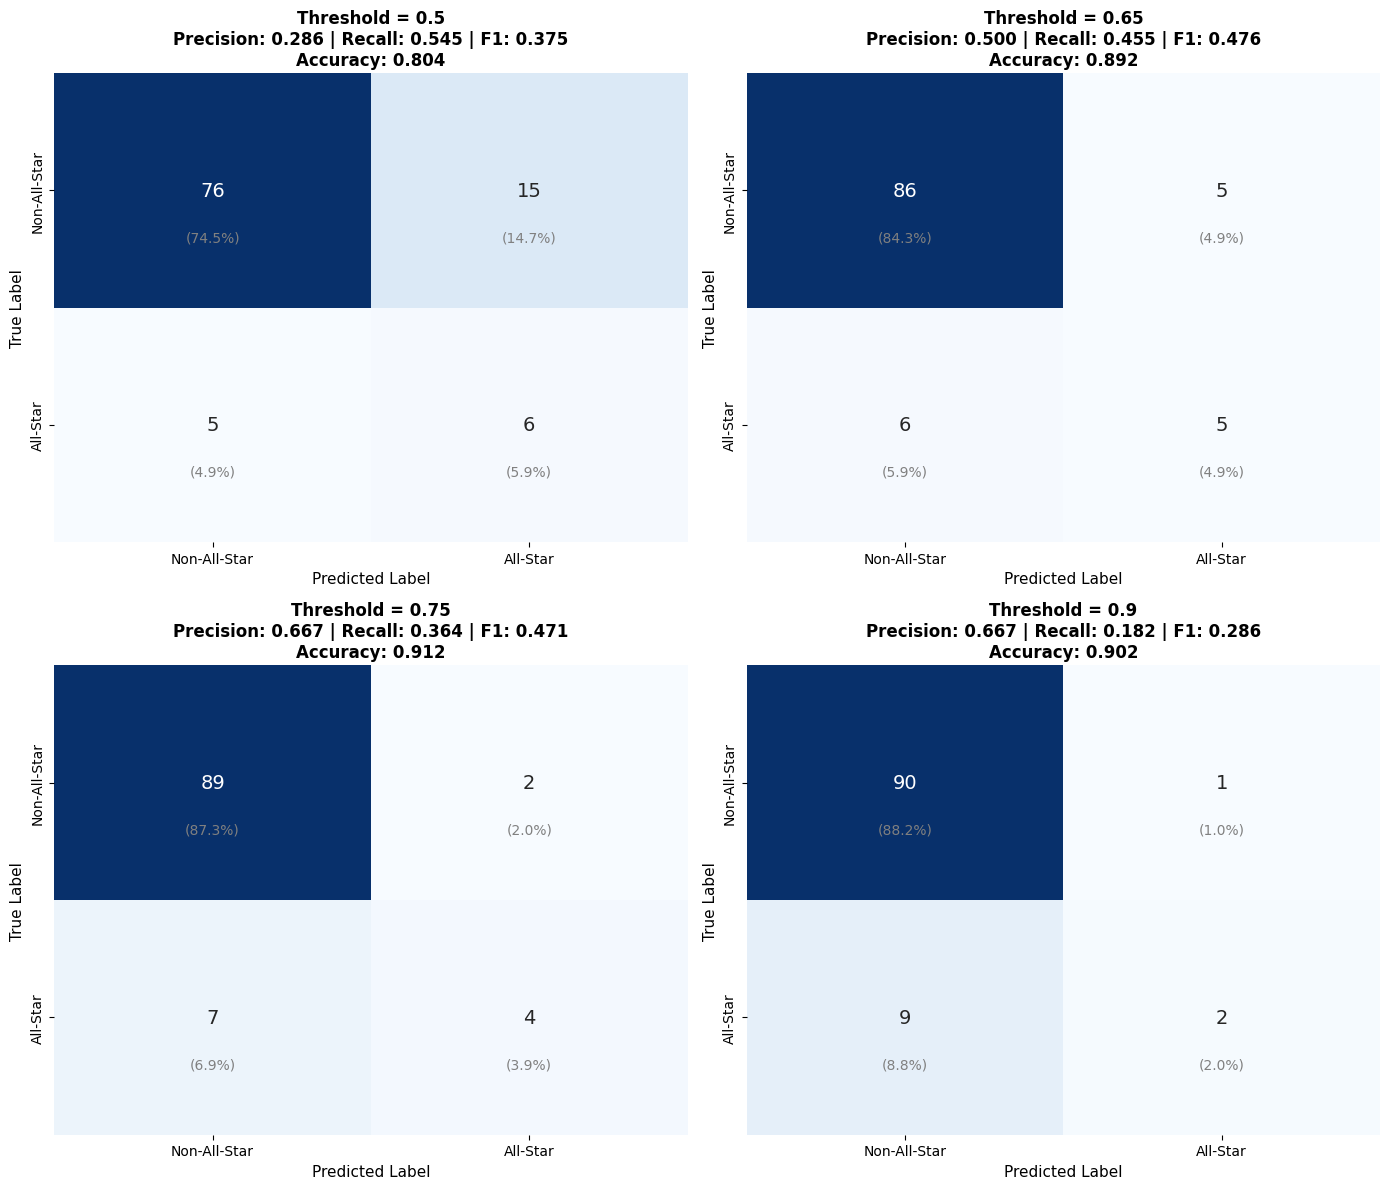


THRESHOLD SWEEP ANALYSIS

Threshold sweep plot saved to: threshold_sweep_20260308.png


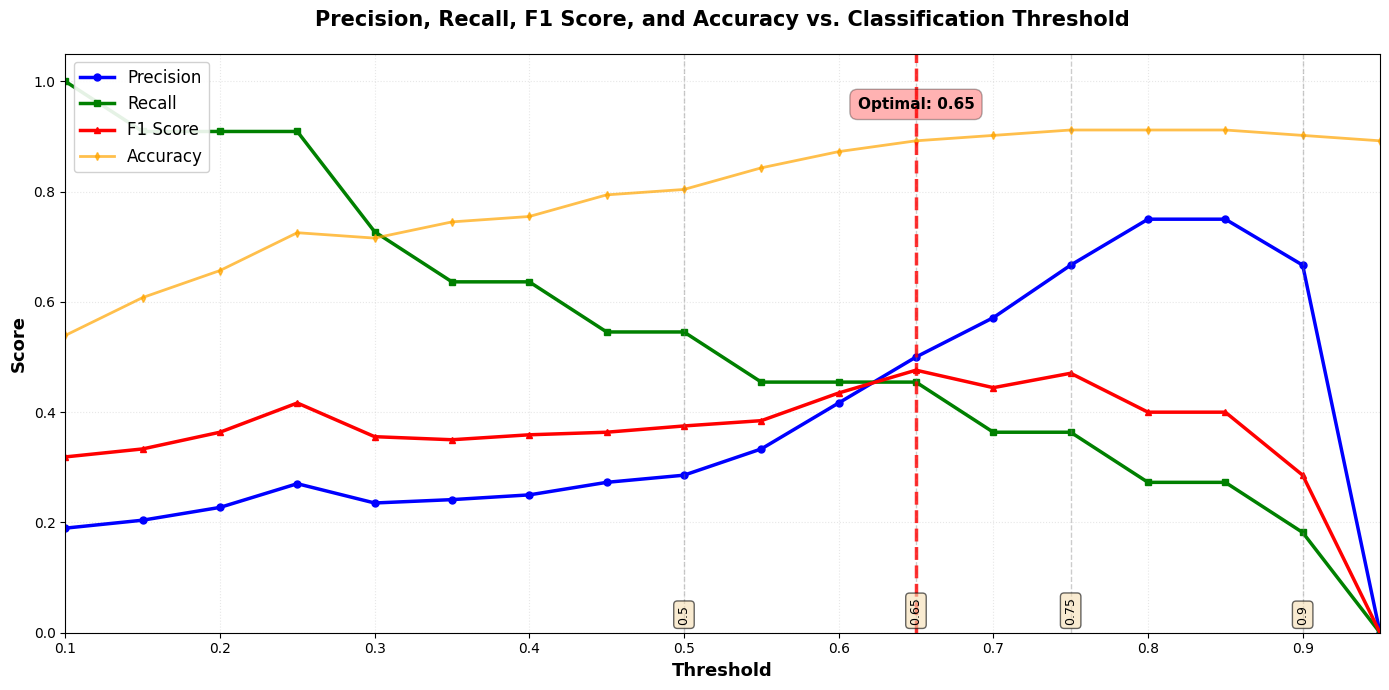


Best F1 Score from sweep: 0.4762 at threshold 0.65
Optimal threshold from training: 0.65


In [201]:
# =============================================================================
# CONFUSION MATRIX ANALYSIS - MULTIPLE THRESHOLDS
# =============================================================================

print("\n" + "=" * 80)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 80 + "\n")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# X_test_combined and y_test_proba were already created during training
# Just get the probabilities from the existing predictions
y_test_proba = best_model.predict_proba(X_test_combined)[:, 1]

# Define thresholds to evaluate
thresholds = [0.5, 0.65, 0.75, 0.9]

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print("Threshold Comparison:")
print("=" * 80)

for idx, threshold in enumerate(thresholds):
    # Apply threshold
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # Print metrics
    print(f"\nThreshold: {threshold}")
    print(f"  Confusion Matrix:")
    print(f"    TN: {tn:3d}  |  FP: {fp:3d}")
    print(f"    FN: {fn:3d}  |  TP: {tp:3d}")
    print(f"  Metrics:")
    print(f"    Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}  |  Accuracy: {accuracy:.3f}")
    print(f"  Predictions:")
    print(f"    All-Stars: {tp + fp} ({(tp+fp)/len(y_test)*100:.1f}%)")
    print(f"    Non-All-Stars: {tn + fn} ({(tn+fn)/len(y_test)*100:.1f}%)")
    
    # Plot confusion matrix
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-All-Star', 'All-Star'],
                yticklabels=['Non-All-Star', 'All-Star'],
                cbar=False, ax=ax, annot_kws={'size': 14})
    
    # Highlight optimal threshold (use best_threshold from training)
    if threshold == best_threshold:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)
    
    # Add title with metrics
    title = f'Threshold = {threshold}'
    if threshold == best_threshold:
        title += ' ⭐ (Optimal)'
    title += f'\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}\n'
    title += f'Accuracy: {accuracy:.3f}'
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    
    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', 
                   ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
cm_file = f'confusion_matrices_thresholds_{date_string}.png'
plt.savefig(cm_file, dpi=300, bbox_inches='tight')
print(f"\n{'='*80}")
print(f"Confusion matrices saved to: {cm_file}")
print(f"{'='*80}")
plt.show()

# =============================================================================
# THRESHOLD SWEEP VISUALIZATION
# =============================================================================

print("\n" + "=" * 80)
print("THRESHOLD SWEEP ANALYSIS")
print("=" * 80 + "\n")

# Sweep through many thresholds
threshold_range = np.arange(0.1, 1.0, 0.05)
precisions = []
recalls = []
f1_scores = []
accuracies = []

for threshold in threshold_range:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    accuracies.append(accuracy)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(threshold_range, precisions, 'b-', linewidth=2.5, label='Precision', marker='o', markersize=5)
ax.plot(threshold_range, recalls, 'g-', linewidth=2.5, label='Recall', marker='s', markersize=5)
ax.plot(threshold_range, f1_scores, 'r-', linewidth=2.5, label='F1 Score', marker='^', markersize=5)
ax.plot(threshold_range, accuracies, 'orange', linewidth=2, label='Accuracy', marker='d', markersize=4, alpha=0.7)

# Mark specific thresholds
for t in [0.5, 0.65, 0.75, 0.9]:
    ax.axvline(t, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    idx_mark = np.argmin(np.abs(threshold_range - t))
    ax.text(t, 0.02, f'{t}', ha='center', fontsize=9, rotation=90,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.6))

# Highlight optimal threshold (use best_threshold from training)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
ax.text(best_threshold, 0.95, f'Optimal: {best_threshold:.2f}', ha='center', fontsize=11, 
        fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.3))

ax.set_xlabel('Threshold', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Precision, Recall, F1 Score, and Accuracy vs. Classification Threshold', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0.1, 0.95)
ax.set_ylim(0, 1.05)

plt.tight_layout()
sweep_file = f'threshold_sweep_{date_string}.png'
plt.savefig(sweep_file, dpi=300, bbox_inches='tight')
print(f"Threshold sweep plot saved to: {sweep_file}")
plt.show()

# Find best F1 threshold from sweep
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = threshold_range[best_f1_idx]
best_f1_value = f1_scores[best_f1_idx]

print(f"\nBest F1 Score from sweep: {best_f1_value:.4f} at threshold {best_f1_threshold:.2f}")
print(f"Optimal threshold from training: {best_threshold:.2f}")
print("=" * 80)

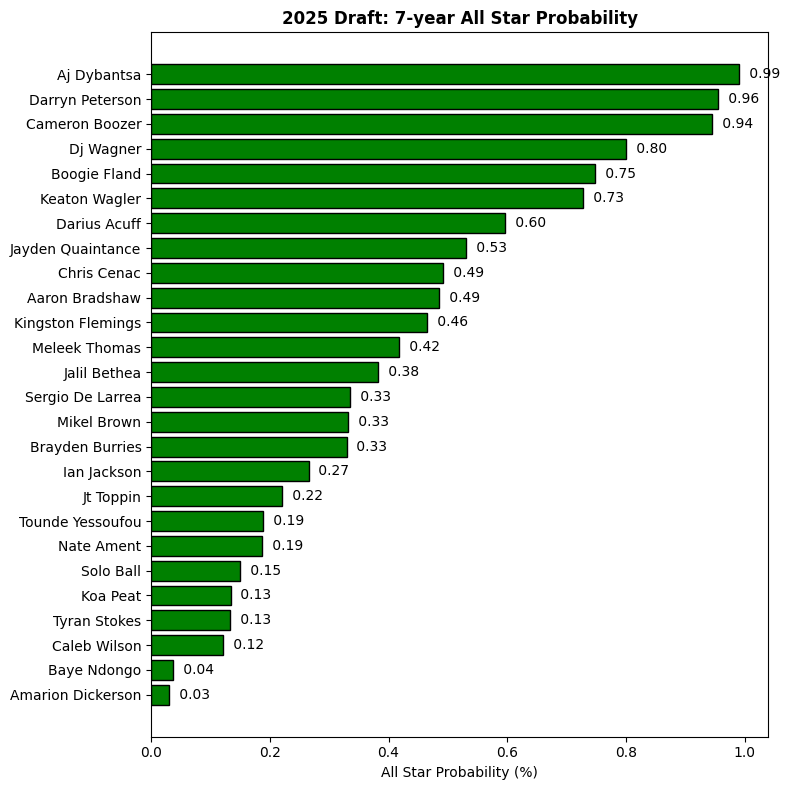

In [194]:
import matplotlib.pyplot as plt
import pandas as pd

predict_df_sorted['player'] = predict_df_sorted['player'].str.replace('-', ' ').str.title()  # Format player names

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(predict_df_sorted['player'], predict_df_sorted['allstar_probability'], color='green', edgecolor='k')

# Set labels and title
ax.set_xlabel('All Star Probability (%)')
# ax.set_ylabel('Player')
ax.set_title('2025 Draft: 7-year All Star Probability', weight='bold')

# Invert the y-axis to show the highest probability at the top
ax.invert_yaxis()

# Add data values to the bars
for i, prob in enumerate(predict_df_sorted['allstar_probability']):
    ax.text(prob + 0.01, i, f' {prob:.2f}', ha='left', va='center')

# Adjust layout and spacing
plt.tight_layout()

# Save the chart as an image
plt.savefig('../outputs/2025_allstar_prob.png', dpi=300, bbox_inches='tight')

# Display the chart
plt.show()